# German title generation — hybrid encoder + autoregressive decoder

Replaces source-position classification with `model(source, title[:, :-1]) → title[:, 1:]`.
The BiLSTM–mLSTM–RWKV encoder reads the article; a causal Transformer decoder attends to its non-padding states. This is a custom model trained from scratch, not a pretrained summarizer or an official xLSTM/RWKV implementation.

Run top to bottom in Colab or Jupyter. Update `DATASET_PATH` and `RUN_DIR`. Old checkpoints are incompatible. No quality improvement is claimed until training and held-out evaluation are complete.

Fixes: independent source/target lengths, teacher forcing, EOS-preserving truncation, autoregressive inference, train-only byte BPE, article-level validation, token-weighted accumulation, gradient clipping, validation-selected checkpoints, and evaluation against real reference strings.

In [ ]:
%pip install torch datasets tokenizers sacrebleu rouge-score tqdm matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 14.7 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24986 sha256=2e6627350075d2e7484867ad9349063ad5c91839c5945a6a4fe94a83d3d7eeb2
  Stored in directory: /root/.cache/pip/wheels/44/af/da/5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge-score


In [ ]:
import time
import os, math, json, random, hashlib
from pathlib import Path
from itertools import islice
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from datasets import load_from_disk
from tokenizers import Tokenizer, ByteLevelBPETokenizer
from tqdm.auto import tqdm
import sacrebleu
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt


In [ ]:

# Mount Google Drive only when running in Colab.
try:
    from google.colab import drive
except ImportError:
    pass
else:
    drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


# Get the current Unix timestamp (seconds since the epoch)
unix_timestamp = time.time()
print(f"Unix Timestamp (seconds since epoch): {unix_timestamp}")

# Get a human-readable formatted timestamp
# You can customize the format string as needed
formatted_timestamp = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(unix_timestamp))
print(f"Formatted Timestamp: {formatted_timestamp}")

SEED = 42
DATASET_PATH = '/content/drive/MyDrive/Dataset/german_text/german_news_titles'
RUN_DIR = Path('/content/drive/MyDrive/Dataset/german_text/hybrid_seq2seq_v2')
evaluation_plt_saved_path = f"/content/drive/MyDrive/Dataset/german_text/hybridModel/plt{formatted_timestamp}"
MAX_INPUT_LEN, MAX_TARGET_LEN = 256, 64
VOCAB_SIZE = 16000
BATCH_SIZE, GRAD_ACCUM_STEPS = 8, 4
EPOCHS, LR = 10, 3e-4
USE_AMP, RESUME = True, False
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(device)

Unix Timestamp (seconds since epoch): 1790475144.3446198
Formatted Timestamp: 2026-09-27 02:12:24
cuda


## Split articles before expanding title pairs
Identical stripped article texts are grouped, and train/test overlap is rejected. All titles from one article stay in one split. The test split is used only for final generation and evaluation.

In [ ]:
dataset = load_from_disk(DATASET_PATH)
def article_groups(split):
    groups = {}
    for row in split:
        text = str(row['text']).strip()
        titles = row['titles']
        if isinstance(titles, str):
            titles = [titles]
        titles = [t.strip() for t in titles if isinstance(t, str) and t.strip()]
        if text and titles:
            groups.setdefault(text, set()).update(titles)
    return [{'input': text, 'references': sorted(titles)} for text, titles in groups.items()]

articles = article_groups(dataset['train'])
test_articles = article_groups(dataset['test'])
assert len(articles) >= 2 and test_articles, 'Need at least two training articles and a nonempty test set.'
assert not ({a['input'] for a in articles} & {a['input'] for a in test_articles}), 'Train/test article overlap: clean the dataset before training.'
rng = random.Random(SEED)
rng.shuffle(articles)
n_val = min(len(articles) - 1, max(1, round(0.1 * len(articles))))
val_articles, train_articles = articles[:n_val], articles[n_val:]
def expand(rows):
    return [{'input': a['input'], 'target': title} for a in rows for title in a['references']]
train_data, val_data = expand(train_articles), expand(val_articles)
print('Articles (train/validation/test):', len(train_articles), len(val_articles), len(test_articles))

Articles (train/validation/test): 759 84 257


In [ ]:
tokenizer_path = RUN_DIR / 'tokenizer.json'
if RESUME:
    if not tokenizer_path.exists():
        raise FileNotFoundError('Resume requires the saved tokenizer.')
    tokenizer = Tokenizer.from_file(str(tokenizer_path))
else:
    if (RUN_DIR / 'last.pt').exists() or (RUN_DIR / 'best.pt').exists():
        raise FileExistsError('Use a new RUN_DIR for a fresh run, or set RESUME=True.')
    bpe = ByteLevelBPETokenizer()
    def training_texts():
        for article in train_articles:
            yield article['input']
            yield from article['references']
    bpe.train_from_iterator(training_texts(), vocab_size=VOCAB_SIZE, min_frequency=2,
                            special_tokens=['<pad>', '<bos>', '<eos>', '<unk>'])
    bpe.save(str(tokenizer_path))
    tokenizer = Tokenizer.from_file(str(tokenizer_path))
assert [tokenizer.token_to_id(t) for t in ['<pad>', '<bos>', '<eos>', '<unk>']] == [0, 1, 2, 3]
vocab_size = tokenizer.get_vocab_size()
tokenizer_hash = hashlib.sha256(tokenizer_path.read_bytes()).hexdigest()
# Includes references and split membership: changing data makes resume fail explicitly.
data_hash = hashlib.sha256(json.dumps([train_articles, val_articles, test_articles], ensure_ascii=False).encode()).hexdigest()

def encode_source(text):
    return tokenizer.encode(text).ids[:MAX_INPUT_LEN - 1] + [EOS_IDX]

def encode_target(text):
    return [SOS_IDX] + tokenizer.encode(text).ids[:MAX_TARGET_LEN - 2] + [EOS_IDX]

class TitleDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        pair = self.pairs[i]
        return torch.tensor(encode_source(pair['input'])), torch.tensor(encode_target(pair['target']))

def collate_pairs(rows):
    sources, targets = zip(*rows)
    return (pad_sequence(sources, batch_first=True, padding_value=PAD_IDX),
            pad_sequence(targets, batch_first=True, padding_value=PAD_IDX))

train_loader = DataLoader(TitleDataset(train_data), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_pairs)
val_loader = DataLoader(TitleDataset(val_data), batch_size=BATCH_SIZE, collate_fn=collate_pairs)

## Model
Source mLSTM still uses quadratic attention-like matrices; recurrent RWKV removes its much larger quadratic-by-channel allocation. Custom encoder arithmetic runs in FP32 for stability. The decoder uses causal self-attention and masked cross-attention ([PyTorch documentation](https://docs.pytorch.org/docs/main/generated/torch.nn.TransformerDecoder.html)). Byte BPE preserves case, punctuation and German characters ([tokenizer implementation](https://github.com/huggingface/tokenizers/blob/main/bindings/python/py_src/tokenizers/implementations/byte_level_bpe.py)).

In [ ]:
"""Custom hybrid encoder and causal cross-attention title decoder."""
import math
import torch
from torch import nn
from torch.nn import functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


# ---------- 2. model blocks ----------
class MLSTMBlock(nn.Module):
    """xLSTM block (mLSTM with matrix memory), parallel quadratic implementation for the source encoder."""

    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.H = n_heads
        self.dh = d_model // n_heads
        self.D = d_model
        self.norm = nn.LayerNorm(d_model)
        self.q = nn.Linear(d_model, d_model, bias=False)
        self.k = nn.Linear(d_model, d_model, bias=False)
        self.v = nn.Linear(d_model, d_model, bias=False)
        self.i_gate = nn.Linear(d_model, n_heads)   # input gate
        self.f_gate = nn.Linear(d_model, n_heads)   # forget gate
        self.o_gate = nn.Linear(d_model, d_model)   # output gate
        self.out_norm = nn.LayerNorm(d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
        nn.init.constant_(self.f_gate.bias, 3.0)    # start with long memory

    def forward(self, x):
        B, T, D = x.shape
        H, dh = self.H, self.dh
        xn = self.norm(x)
        q = self.q(xn).float().view(B, T, H, dh).transpose(1, 2)                    # (B, H, T, dh)
        k = (self.k(xn).float().view(B, T, H, dh) / math.sqrt(dh)).transpose(1, 2)  # (B, H, T, dh)
        v = self.v(xn).float().view(B, T, H, dh).transpose(1, 2)                    # (B, H, T, dh)
        i_pre = self.i_gate(xn).float().transpose(1, 2)                             # (B, H, T)
        log_f = F.logsigmoid(self.f_gate(xn).float()).transpose(1, 2)               # (B, H, T)
        o = torch.sigmoid(self.o_gate(xn))                                  # (B, T, D)

        # Parallel form of the mLSTM recurrence: gives the same result as the
        # step-by-step loop, but all time steps are computed at once (much faster).
        F_cum = torch.cumsum(log_f, dim=-1)                                 # (B, H, T)
        gate = F_cum.unsqueeze(-1) - F_cum.unsqueeze(-2) + i_pre.unsqueeze(-2)   # (B, H, T, T)
        causal = torch.tril(torch.ones(T, T, dtype=torch.bool, device=x.device))
        gate = gate.masked_fill(~causal, float("-inf"))                     # token t only sees s <= t
        m = torch.maximum(gate.max(dim=-1).values, F_cum)                   # stabiliser (B, H, T)
        weights = torch.exp(gate - m.unsqueeze(-1))                         # (B, H, T, T)

        scores = torch.matmul(q, k.transpose(-1, -2)) * weights             # (B, H, T, T)
        den = scores.sum(dim=-1).abs()
        den = torch.maximum(den, torch.exp(-m)) + 1e-6                      # (B, H, T)
        h = torch.matmul(scores, v) / den.unsqueeze(-1)                     # (B, H, T, dh)
        h = h.transpose(1, 2).reshape(B, T, D)                              # (B, T, D)

        h = self.out(self.out_norm(h) * o)
        return x + self.drop(h)


def token_shift(x):
    """Shift x one step to the right in time (first position gets zeros)."""
    return torch.cat([torch.zeros_like(x[:, :1]), x[:, :-1]], dim=1)


class RWKVTimeMix(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.mu_k = nn.Parameter(torch.full((d_model,), 0.5))
        self.mu_v = nn.Parameter(torch.full((d_model,), 0.5))
        self.mu_r = nn.Parameter(torch.full((d_model,), 0.5))
        self.time_decay = nn.Parameter(torch.linspace(-5.0, 1.0, d_model))
        self.time_first = nn.Parameter(torch.zeros(d_model))
        self.key = nn.Linear(d_model, d_model, bias=False)
        self.value = nn.Linear(d_model, d_model, bias=False)
        self.receptance = nn.Linear(d_model, d_model, bias=False)
        self.output = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        xx = token_shift(x)
        k = self.key(x * self.mu_k + xx * (1 - self.mu_k))
        v = self.value(x * self.mu_v + xx * (1 - self.mu_v))
        r = torch.sigmoid(self.receptance(x * self.mu_r + xx * (1 - self.mu_r)))

        w = -torch.exp(self.time_decay.float())             # per-channel decay (negative)
        u = self.time_first                         # bonus for the current token

        # Stable recurrent WKV avoids allocating (B, T, T, D).
        # FP32 states; time loop trades throughput for lower activation memory.
        k, v, w, u = k.float(), v.float(), w.float(), u.float()
        aa = torch.zeros(B, D, device=x.device)
        bb = torch.zeros_like(aa)
        pp = torch.full_like(aa, -float("inf"))
        outputs = []
        for t in range(T):
            current = u + k[:, t]
            p = torch.maximum(pp, current)
            e1, e2 = torch.exp(pp - p), torch.exp(current - p)
            outputs.append((e1 * aa + e2 * v[:, t]) / (e1 * bb + e2).clamp_min(1e-8))
            decayed = pp + w
            p = torch.maximum(decayed, k[:, t])
            e1, e2 = torch.exp(decayed - p), torch.exp(k[:, t] - p)
            aa = e1 * aa + e2 * v[:, t]
            bb = e1 * bb + e2
            pp = p
        wkv = torch.stack(outputs, dim=1).to(r.dtype)

        return self.output(r * wkv)


class RWKVChannelMix(nn.Module):
    def __init__(self, d_model, expansion=4):
        super().__init__()
        self.mu_k = nn.Parameter(torch.full((d_model,), 0.5))
        self.mu_r = nn.Parameter(torch.full((d_model,), 0.5))
        self.key = nn.Linear(d_model, expansion * d_model, bias=False)
        self.value = nn.Linear(expansion * d_model, d_model, bias=False)
        self.receptance = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        xx = token_shift(x)
        k = self.key(x * self.mu_k + xx * (1 - self.mu_k))
        r = torch.sigmoid(self.receptance(x * self.mu_r + xx * (1 - self.mu_r)))
        return r * self.value(torch.relu(k) ** 2)


class RWKVBlock(nn.Module):
    def __init__(self, d_model, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.time_mix = RWKVTimeMix(d_model)
        self.chan_mix = RWKVChannelMix(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.drop(self.time_mix(self.ln1(x)))
        x = x + self.drop(self.chan_mix(self.ln2(x)))
        return x


class HybridSeq2Seq(nn.Module):
    """Right-padded source -> autoregressive title; logits follow TARGET length."""
    def __init__(self, vocab_size, embed_dim=256, hidden=256, n_heads=8,
                 head_hidden=1024, dropout=0.15, decoder_layers=2,
                 max_target_len=64, pad_idx=0, bos_idx=1, eos_idx=2):
        super().__init__()
        if hidden % n_heads:
            raise ValueError("hidden must be divisible by n_heads")
        self.pad_idx, self.bos_idx, self.eos_idx = pad_idx, bos_idx, eos_idx
        self.max_target_len = max_target_len
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embed_drop = nn.Dropout(dropout)
        self.bilstm = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=True)
        self.bilstm_proj = nn.Linear(2 * hidden, hidden)
        self.xlstm = MLSTMBlock(hidden, n_heads, dropout)
        self.rwkv = RWKVBlock(hidden, dropout)
        self.final_norm = nn.LayerNorm(hidden)
        self.target_proj = nn.Linear(embed_dim, hidden) if embed_dim != hidden else nn.Identity()
        self.positions = nn.Embedding(max_target_len, hidden)
        # Construct separately so decoder layers do not start with identical weights.
        self.decoder = nn.ModuleList([
            nn.TransformerDecoderLayer(hidden, n_heads, head_hidden, dropout,
                                       activation="gelu", batch_first=True, norm_first=True)
            for _ in range(decoder_layers)
        ])
        self.decoder_norm = nn.LayerNorm(hidden)
        self.output_layer = nn.Linear(hidden, vocab_size)

    def encode(self, source):
        padding = source.eq(self.pad_idx)
        lengths = (~padding).sum(1)
        if (lengths == 0).any():
            raise ValueError("Every source must contain a token (use EOS for empty text).")
        if ((~padding[:, 1:]) & padding[:, :-1]).any():
            raise ValueError("Sources must be right-padded.")
        x = self.embed_drop(self.embed(source))
        x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        x, _ = self.bilstm(x)
        x, _ = pad_packed_sequence(x, batch_first=True, total_length=source.size(1))
        x = self.bilstm_proj(x).masked_fill(padding.unsqueeze(-1), 0)
        # These source blocks are causal; trailing pads cannot affect real positions.
        # Disable AMP for the custom recurrence and mLSTM matrix products.
        with torch.autocast(device_type=source.device.type, enabled=False):
            x = self.xlstm(x.float()).masked_fill(padding.unsqueeze(-1), 0)
            x = self.rwkv(x).masked_fill(padding.unsqueeze(-1), 0)
        return self.final_norm(x).masked_fill(padding.unsqueeze(-1), 0), padding

    def decode(self, target_input, memory, source_padding):
        t = target_input.size(1)
        if not 1 <= t <= self.max_target_len:
            raise ValueError("Target prefix length exceeds positional capacity.")
        x = self.target_proj(self.embed(target_input))
        x = self.embed_drop(x + self.positions(torch.arange(t, device=x.device)))
        causal = torch.ones(t, t, dtype=torch.bool, device=x.device).triu(1)
        for layer in self.decoder:
            x = layer(x, memory, tgt_mask=causal,
                      tgt_key_padding_mask=target_input.eq(self.pad_idx),
                      memory_key_padding_mask=source_padding)
        return self.output_layer(self.decoder_norm(x))

    def forward(self, source, target_input):
        memory, padding = self.encode(source)
        return self.decode(target_input, memory, padding)

    @torch.inference_mode()
    def generate(self, source, max_new_tokens=None):
        """Greedy decoding; encode once, stop each row at EOS. No decoder KV cache."""
        limit = self.max_target_len - 1 if max_new_tokens is None else max_new_tokens
        if not 1 <= limit < self.max_target_len:
            raise ValueError("max_new_tokens must be in [1, max_target_len - 1]")
        was_training = self.training
        self.eval()
        try:
            memory, padding = self.encode(source)
            ids = source.new_full((source.size(0), 1), self.bos_idx)
            done = torch.zeros(source.size(0), dtype=torch.bool, device=source.device)
            for _ in range(limit):
                logits = self.decode(ids, memory, padding)[:, -1].clone()
                logits[:, [self.pad_idx, self.bos_idx]] = -float("inf")
                next_id = logits.argmax(-1).masked_fill(done, self.pad_idx)
                ids = torch.cat([ids, next_id[:, None]], dim=1)
                done |= next_id.eq(self.eos_idx)
                if done.all():
                    break
            return ids
        finally:
            self.train(was_training)

In [ ]:
model_config = dict(vocab_size=vocab_size, embed_dim=256, hidden=256, n_heads=8,
                    head_hidden=1024, dropout=0.15, decoder_layers=2,
                    max_target_len=MAX_TARGET_LEN, pad_idx=PAD_IDX, bos_idx=SOS_IDX, eos_idx=EOS_IDX)
model = HybridSeq2Seq(**model_config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
amp_enabled = USE_AMP and device.type == 'cuda'
scaler = torch.amp.GradScaler(device.type, enabled=amp_enabled)
run_config = dict(max_input_len=MAX_INPUT_LEN, batch_size=BATCH_SIZE,
                  accumulation=GRAD_ACCUM_STEPS, lr=LR, seed=SEED, amp=amp_enabled)
print(f'{sum(p.numel() for p in model.parameters()):,} parameters')

12,704,400 parameters


## Training and checkpoints
Each accumulation window divides summed cross-entropy by its exact number of non-padding labels, including the final partial window. Validation uses unsmoothed token loss. There is no unsafe recursive OOM retry: reduce `BATCH_SIZE` and increase accumulation if needed. Epoch-boundary resume restores optimizer, scaler, tokenizer identity and RNG state; `best.pt` and `last.pt` are separate.

In [ ]:
def save_checkpoint(path, epoch, best_loss):
    state = dict(version=2, epoch=epoch, best_loss=best_loss, model_config=model_config,
                 run_config=run_config, tokenizer_hash=tokenizer_hash, data_hash=data_hash,
                 model=model.state_dict(), optimizer=optimizer.state_dict(), scaler=scaler.state_dict(),
                 torch_rng=torch.get_rng_state(), python_rng=random.getstate(),
                 cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else [])
    temp = path.with_suffix('.tmp')
    torch.save(state, temp)
    os.replace(temp, path)

def checked_checkpoint(path):
    state = torch.load(path, map_location='cpu', weights_only=True)
    for key, expected in [('version', 2), ('model_config', model_config), ('run_config', run_config),
                          ('tokenizer_hash', tokenizer_hash), ('data_hash', data_hash)]:
        if state.get(key) != expected:
            raise ValueError(f'Incompatible checkpoint: {key}')
    return state

start_epoch, best_loss = 0, float('inf')
if RESUME:
    state = checked_checkpoint(RUN_DIR / 'last.pt')
    model.load_state_dict(state['model'], strict=True)
    optimizer.load_state_dict(state['optimizer'])
    scaler.load_state_dict(state['scaler'])
    torch.set_rng_state(state['torch_rng'])
    random.setstate(state['python_rng'])
    if device.type == 'cuda' and state['cuda_rng']:
        torch.cuda.set_rng_state_all(state['cuda_rng'])
    start_epoch, best_loss = state['epoch'] + 1, state['best_loss']
    del state

@torch.no_grad()
def validation_loss():
    model.eval()
    total, count = 0.0, 0
    for source, target in val_loader:
        source, target = source.to(device), target.to(device)
        labels = target[:, 1:]
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(source, target[:, :-1])
            loss = F.cross_entropy(logits.reshape(-1, vocab_size), labels.reshape(-1),
                                   ignore_index=PAD_IDX, reduction='sum')
        total += loss.item()
        count += labels.ne(PAD_IDX).sum().item()
    return total / count

for epoch in range(start_epoch, EPOCHS):
    model.train()
    iterator = iter(train_loader)
    total, count = 0.0, 0
    progress = tqdm(total=math.ceil(len(train_loader) / GRAD_ACCUM_STEPS), desc=f'Epoch {epoch+1}')
    while True:
        window = list(islice(iterator, GRAD_ACCUM_STEPS))
        if not window:
            break
        token_count = sum(target[:, 1:].ne(PAD_IDX).sum().item() for _, target in window)
        optimizer.zero_grad(set_to_none=True)
        for source, target in window:
            source, target = source.to(device), target.to(device)
            labels = target[:, 1:]
            with torch.autocast(device_type=device.type, enabled=amp_enabled):
                logits = model(source, target[:, :-1])
                loss_sum = F.cross_entropy(logits.reshape(-1, vocab_size), labels.reshape(-1),
                                           ignore_index=PAD_IDX, reduction='sum', label_smoothing=0.1)
            scaler.scale(loss_sum / token_count).backward()
            total += loss_sum.item()
        count += token_count
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        progress.update(1)
        progress.set_postfix(train_loss=total/count)
    progress.close()
    val_loss = validation_loss()
    if not math.isfinite(val_loss):
        raise FloatingPointError('Non-finite validation loss; checkpoint not saved.')
    print(f'Train smoothed CE: {total/count:.4f}; validation CE: {val_loss:.4f}')
    if val_loss < best_loss:
        best_loss = val_loss
        save_checkpoint(RUN_DIR / 'best.pt', epoch, best_loss)
    save_checkpoint(RUN_DIR / 'last.pt', epoch, best_loss)

Epoch 1:   0%|          | 0/468 [00:00<?, ?it/s]

Train smoothed CE: 6.6158; validation CE: 5.8580


Epoch 2:   0%|          | 0/468 [00:00<?, ?it/s]

Train smoothed CE: 5.7206; validation CE: 5.4848


Epoch 3:   0%|          | 0/468 [00:00<?, ?it/s]

...

Train smoothed CE: 4.0174; validation CE: 4.7979


Epoch 9:   0%|          | 0/468 [00:00<?, ?it/s]

Train smoothed CE: 3.8488; validation CE: 4.7721


Epoch 10:   0%|          | 0/468 [00:00<?, ?it/s]

Train smoothed CE: 3.7060; validation CE: 4.7982


## Autoregressive test generation
Generate once per article, with all its titles retained as references. Greedy decoding encodes the article once but recomputes the growing decoder prefix; it has no KV cache or beam search. Generation stops at EOS or the configured token limit.

In [ ]:
state = checked_checkpoint(RUN_DIR / 'best.pt')
model.load_state_dict(state['model'], strict=True)
model.eval()
del state
predictions = []
for start in tqdm(range(0, len(test_articles), BATCH_SIZE), desc='Generating'):
    articles_batch = test_articles[start:start+BATCH_SIZE]
    source = pad_sequence([torch.tensor(encode_source(a['input'])) for a in articles_batch],
                          batch_first=True, padding_value=PAD_IDX).to(device)
    ids = model.generate(source)
    predictions.extend(tokenizer.decode(row, skip_special_tokens=True).strip() for row in ids.cpu().tolist())
references = [a['references'] for a in test_articles]
for i in range(min(5, len(predictions))):
    print('Article:', test_articles[i]['input'][:150])
    print('Generated:', predictions[i])
    print('References:', references[i], '\n')

Generating:   0%|          | 0/33 [00:00<?, ?it/s]

Article: Luftverschmutzung ist ein globales Umweltproblem, das immer dringlicher wird. Die Belastung durch Feinstaub und Stickstoffoxide hat in vielen europäis
Generated: Die Bedeutung von Prävention und Aufklärung zur Reduzierung von Luftverschmutzung in Deutschland
References: ['Atemnot für Anwohner: Die hohe Luftverschmutzung in deutschen Metropolen', 'Die Kosten der Luftverschmutzung - ein verheerendes Umweltproblem für Deutschland', 'Die dunkle Seite des Verkehrs - Luftverschmutzung in europäischen Städten', 'Die unheilige Allianz von Verkehr und Luftverschmutzung - wie wir ihnen begegnen können', 'Die unsichtbare Gefahr - wie Luftverschmutzung das öffentliche Leben beeinträchtigt', 'Fahrverbote, Radwege und Elektroautos: Maßnahmen gegen Luftverschmutzung in Städten', 'Luftreiniger gesucht: Wie Feinstaub und Stickstoffoxide das Leben beeinträchtigen', 'Luftreiniger oder Umweltsünder? Die Verantwortung jedes Einzelnen für die Luftverschmutzung', 'Luftverschmutzung - eine globale He

## Multi-reference evaluation
BLEU and chrF use all references. ROUGE reports the best F1 against any reference for each metric and article. A Unicode word tokenizer preserves umlauts; no English stemming is applied. Exact match ignores case and surrounding whitespace. Length ratio compares with mean reference word count. These conventions must match when comparing models.

{
  "BLEU": 24.953788516218218,
  "chrF": 44.37161527876757,
  "ROUGE-1": 45.84704288750819,
  "ROUGE-2": 26.373773472131834,
  "ROUGE-L": 42.99887714454407,
  "Exact Match": 0.0,
  "Length Ratio": 0.9873190063221625
}


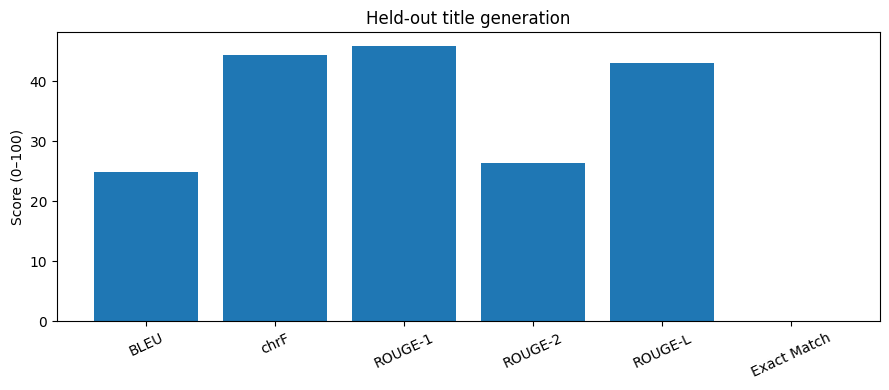

In [ ]:
import re
class UnicodeWords:
    def tokenize(self, text):
        return re.findall(r"\w+", text.casefold(), flags=re.UNICODE)

assert len(predictions) == len(references) and predictions
n_refs = max(map(len, references))
# Repeat a valid reference where a row has fewer titles; this adds no new reference content.
ref_streams = [[refs[j] if j < len(refs) else refs[0] for refs in references] for j in range(n_refs)]
bleu_score = sacrebleu.corpus_bleu(predictions, ref_streams).score
chrf_score = sacrebleu.corpus_chrf(predictions, ref_streams).score
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], tokenizer=UnicodeWords(), use_stemmer=False)
rouge_rows = []
for pred, refs in zip(predictions, references):
    scores = [scorer.score(ref, pred) for ref in refs]
    rouge_rows.append({key: max(s[key].fmeasure for s in scores) for key in scores[0]})
rouge_1, rouge_2, rouge_l = [100 * np.mean([row[key] for row in rouge_rows]) for key in ['rouge1', 'rouge2', 'rougeL']]
exact_match = 100 * np.mean([any(p.casefold().strip() == ref.casefold().strip() for ref in refs) for p, refs in zip(predictions, references)])
length_ratio = np.mean([len(p.split()) / np.mean([len(ref.split()) for ref in refs]) for p, refs in zip(predictions, references)])
metrics = {'BLEU': float(bleu_score), 'chrF': float(chrf_score), 'ROUGE-1': float(rouge_1),
           'ROUGE-2': float(rouge_2), 'ROUGE-L': float(rouge_l), 'Exact Match': float(exact_match),
           'Length Ratio': float(length_ratio)}
print(json.dumps(metrics, indent=2))
(RUN_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))
(RUN_DIR / 'predictions.json').write_text(json.dumps([
    dict(prediction=p, references=refs) for p, refs in zip(predictions, references)
], ensure_ascii=False, indent=2))
fig, ax = plt.subplots(figsize=(9, 4))
plot_metrics = {k: v for k, v in metrics.items() if k != 'Length Ratio'}
ax.bar(plot_metrics.keys(), plot_metrics.values())
ax.set_ylabel('Score (0–100)')
ax.set_title('Held-out title generation')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
fig.savefig(f"{evaluation_plt_saved_path}.png")
plt.close(fig)